# Model Evaluation Visualizations

This notebook loads the trained MONAI ResNet-18 brain tumor classifier, runs evaluation on the **test set**, and produces:

- **Confusion matrix** (heatmap)
- **ROC curve** and AUC
- **Precision–Recall curve** and average precision
- **Classification report** (precision, recall, F1)
- **Sample predictions** (grid of test images with predicted vs. ground-truth labels)

**Requirements:** Run training first so that `outputs/best_resnet18.pth` exists. Set `DATA_ROOT` and `MODEL_PATH` in the next cell if your paths differ.

In [10]:
# Configuration and imports
import os
import sys
import random
from glob import glob
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import train_test_split

from monai.data import ImageDataset, DataLoader
from monai.networks.nets import resnet18
from monai.transforms import (
    Compose,
    EnsureChannelFirst,
    Lambda,
    Resize,
    ScaleIntensity,
    ToTensor,
)

# --- Config (edit if needed) ---
DATA_DIR = "data"           # folder layout: data/train, data/val, data/test (preferred)
DATA_ROOT = "data/raw_data"  # fallback: single dir with tumor/no_tumor, notebook infers test via 70/15/15
MODEL_PATH = "outputs/best_resnet18.pth"
OUTPUT_DIR = "outputs"
SEED = 42
BATCH_SIZE = 16

os.makedirs(OUTPUT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Model path: {MODEL_PATH}")
print(f"Data dir (folder layout): {DATA_DIR}")

Using device: cpu
Model path: outputs/best_resnet18.pth
Data dir (folder layout): data


In [11]:
# Load data and build test dataloader
def collect_image_paths_and_labels(data_root: str) -> Tuple[List[str], List[int]]:
    exts = ("*.png", "*.jpg", "*.jpeg", "*.bmp")
    image_paths = []
    for ext in exts:
        pattern = os.path.join(data_root, "*", ext)
        image_paths.extend(glob(pattern))
    if not image_paths:
        raise FileNotFoundError(f"No images under '{data_root}' (expect 'tumor/' and 'no_tumor/').")
    labels = []
    for p in image_paths:
        class_name = os.path.basename(os.path.dirname(p)).lower()
        labels.append(0 if class_name == "no_tumor" else 1)
    return image_paths, labels

def get_eval_transforms():
    return Compose([
        EnsureChannelFirst(),
        Lambda(lambda x: x.mean(axis=0, keepdims=True) if x.shape[0] != 1 else x),
        ScaleIntensity(),
        Resize((224, 224)),
        ToTensor(),
    ])

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

test_dir = os.path.join(DATA_DIR, "test")
use_folder = os.path.isdir(test_dir)
if use_folder:
    try:
        test_imgs, test_labels = collect_image_paths_and_labels(test_dir)
        if test_imgs:
            print(f"Using folder layout: {test_dir}")
        else:
            use_folder = False
    except FileNotFoundError:
        use_folder = False
if not use_folder:
    print("Folder layout not found; using DATA_ROOT and 70/15/15 split.")
    image_paths, labels = collect_image_paths_and_labels(DATA_ROOT)
    train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
        image_paths, labels, test_size=0.30, stratify=labels, random_state=SEED
    )
    val_imgs, test_imgs, val_labels, test_labels = train_test_split(
        temp_imgs, temp_labels, test_size=0.50, stratify=temp_labels, random_state=SEED
    )

eval_tf = get_eval_transforms()
test_ds = ImageDataset(test_imgs, labels=test_labels, transform=eval_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print(f"Test set size: {len(test_imgs)}")
class_names = ["No Tumor", "Tumor"]

Using folder layout: data\test
Test set size: 1816


In [12]:
# Load model and run evaluation (predictions + probabilities for ROC/PR)
def load_model(device):
    model = resnet18(spatial_dims=2, n_input_channels=1, num_classes=2)
    state = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(state)
    model.to(device)
    model.eval()
    return model

def evaluate_with_probs(model, loader, device):
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)
            all_labels.extend(y.numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

model = load_model(device)
y_true, y_pred, y_probs = evaluate_with_probs(model, test_loader, device)
# Probability of positive class (Tumor) for ROC/PR
y_score = y_probs[:, 1]

test_acc = (y_pred == y_true).mean()
print(f"Test accuracy: {test_acc:.2%}")
print(f"Test set size: {len(y_true)}")

Test accuracy: 97.96%
Test set size: 1816


## 1. Confusion matrix

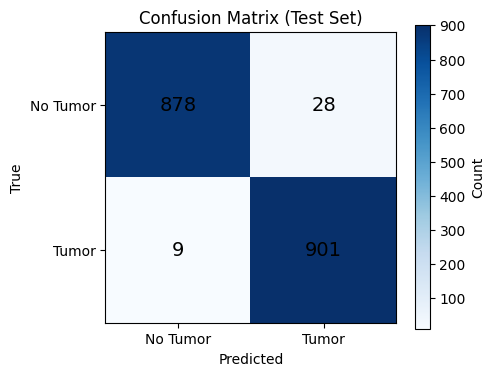

Saved: outputs/confusion_matrix.png


In [13]:
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.colorbar(im, ax=ax, label="Count")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=14)
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/confusion_matrix.png")

## 2. ROC curve and AUC

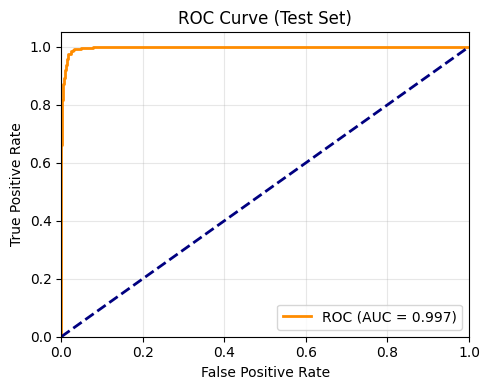

Saved: outputs/roc_curve.png


In [14]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/roc_curve.png")

## 3. Precision–Recall curve

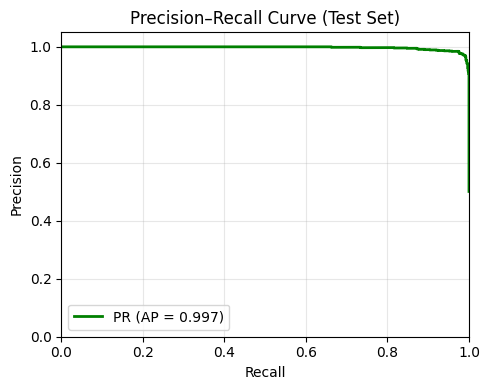

Saved: outputs/precision_recall_curve.png


In [15]:
precision, recall, _ = precision_recall_curve(y_true, y_score)
avg_precision = average_precision_score(y_true, y_score)
plt.figure(figsize=(5, 4))
plt.plot(recall, precision, color="green", lw=2, label=f"PR (AP = {avg_precision:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_curve.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/precision_recall_curve.png")

## 4. Classification report

              precision    recall  f1-score   support

    No Tumor      0.990     0.969     0.979       906
       Tumor      0.970     0.990     0.980       910

    accuracy                          0.980      1816
   macro avg      0.980     0.980     0.980      1816
weighted avg      0.980     0.980     0.980      1816



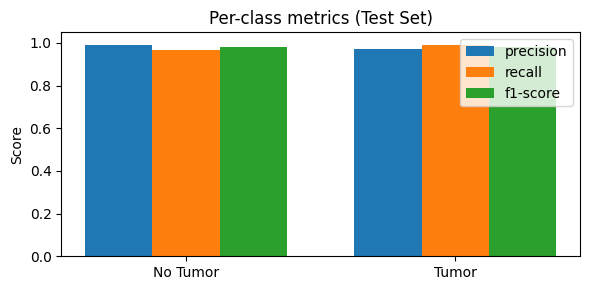

Saved: outputs/classification_report_bars.png


In [16]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
# Optional: bar chart of per-class metrics
fig, ax = plt.subplots(figsize=(6, 3))
metrics = ["precision", "recall", "f1-score"]
x = np.arange(len(class_names))
width = 0.25
for i, m in enumerate(metrics):
    vals = [report[c][m] for c in class_names]
    ax.bar(x + i * width, vals, width, label=m)
ax.set_ylabel("Score")
ax.set_xticks(x + width)
ax.set_xticklabels(class_names)
ax.legend()
ax.set_ylim(0, 1.05)
plt.title("Per-class metrics (Test Set)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "classification_report_bars.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/classification_report_bars.png")

## 5. Sample predictions (grid)

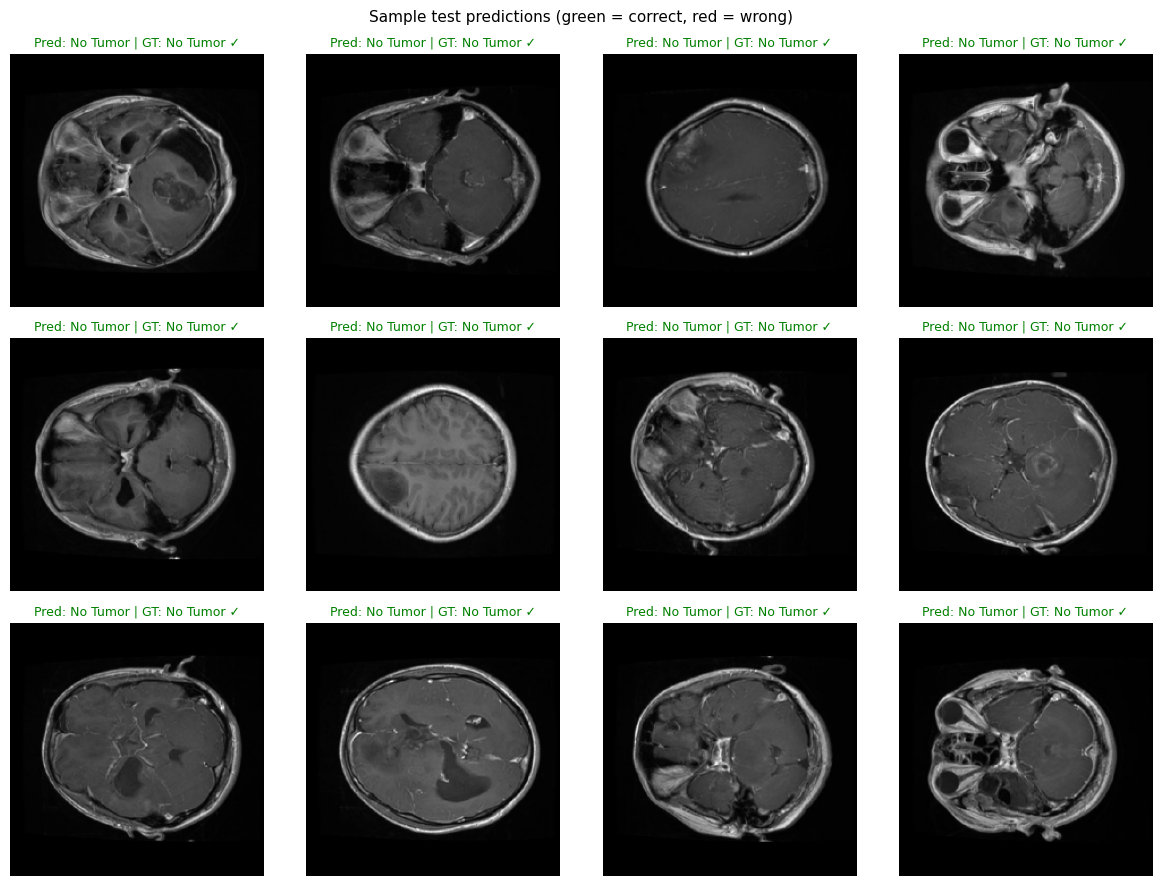

Saved: outputs/sample_predictions_grid.png


In [17]:
# Show a grid of test images with predicted vs. ground-truth labels
n_show = 12  # number of samples to display
n_cols = 4
n_rows = (n_show + n_cols - 1) // n_cols
batch = next(iter(test_loader))
x_batch, y_batch = batch
with torch.no_grad():
    logits = model(x_batch.to(device))
    pred_batch = logits.argmax(dim=1).cpu().numpy()
x_batch = x_batch.cpu()
y_batch = y_batch.numpy()
n_show = min(n_show, x_batch.shape[0])
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = axes.flatten()
for i in range(n_show):
    ax = axes[i]
    img = x_batch[i][0].numpy()
    pred = pred_batch[i]
    true = y_batch[i]
    ax.imshow(img, cmap="gray")
    correct = "✓" if pred == true else "✗"
    color = "green" if pred == true else "red"
    ax.set_title(f"Pred: {class_names[pred]} | GT: {class_names[true]} {correct}", fontsize=9, color=color)
    ax.axis("off")
for j in range(n_show, len(axes)):
    axes[j].axis("off")
plt.suptitle("Sample test predictions (green = correct, red = wrong)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_predictions_grid.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/sample_predictions_grid.png")

## 6. Summary

In [18]:
summary = {
    "Test accuracy": test_acc,
    "ROC AUC": roc_auc,
    "Average precision": avg_precision,
}
print("Evaluation summary:")
for k, v in summary.items():
    print(f"  {k}: {v:.4f}")
print("\nFigures saved to", OUTPUT_DIR)

Evaluation summary:
  Test accuracy: 0.9796
  ROC AUC: 0.9974
  Average precision: 0.9972

Figures saved to outputs
